# K-Nearest Neighbors (KNN) Classification

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X = pd.read_csv('Iris.csv')

In [3]:
X.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Data Preprocessing
First step is to separate the Target variable.

Copy the 'Species' column onto another series called y and drop it from X

In [4]:
y = X.Species.copy()
X.drop(['Species'], axis=1, inplace=True)
y_original = y

Fix the invalid values by filling each row's NaNs with the mean of the feature.


In [5]:
X.fillna(X.mean(), inplace=True)

## 1. Normalize Feature

Create an instance of SKLearn's Normalizer class and then train it using its .fit() method against the training data. Then with the trained pre-processor, transform both training and testing data.


In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [8]:
from sklearn import preprocessing
normaliser = preprocessing.Normalizer().fit(X_train)

In [9]:
X_train_normalised = normaliser.transform(X_train)
X_train = pd.DataFrame(X_train_normalised)

X_test_normalised = normaliser.transform(X_test)
X_test = pd.DataFrame(X_test_normalised)

## Apply PCA transformation

In [10]:
from sklearn.decomposition import PCA
pca_reducer = PCA(n_components=2).fit(X_train_normalised)

X_train_pca = pca_reducer.transform(X_train_normalised)
X_test_pca = pca_reducer.transform(X_test_normalised)

## 2. KNeighborsClassifier
For K-Neighbours, generally the higher your "K" value, the smoother and less complex your decision surface becomes. Higher K values also result in your model providing probabilistic information about the ratio of samples per each class. 

In [11]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_pca, y_train) 

KNeighborsClassifier(n_neighbors=9)

## 3. Accuracy Evaluation

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy_scores = []

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)
    print(f"K={k} --> Accuracy: {acc:.2f}")

K=1 --> Accuracy: 1.00
K=2 --> Accuracy: 1.00
K=3 --> Accuracy: 0.97
K=4 --> Accuracy: 0.93
K=5 --> Accuracy: 0.97
K=6 --> Accuracy: 1.00
K=7 --> Accuracy: 0.97
K=8 --> Accuracy: 0.97
K=9 --> Accuracy: 0.97
K=10 --> Accuracy: 0.97


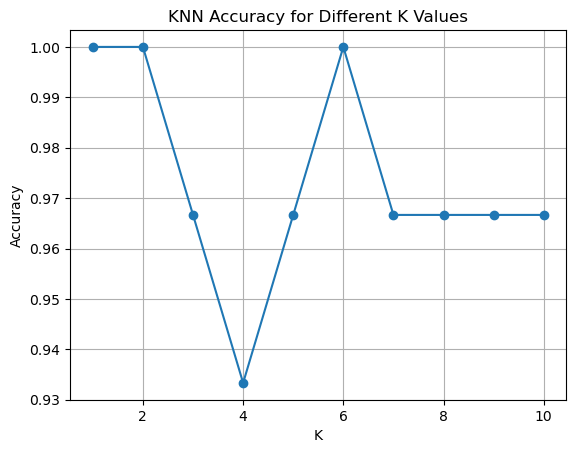

In [13]:
plt.plot(range(1, 11), accuracy_scores, marker='o')
plt.title('KNN Accuracy for Different K Values')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

## 4. Confusion Matrix
In this step the best K i.e, the one with highest accuracy is choosen

In [14]:
best_k = np.argmax(accuracy_scores) + 1
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

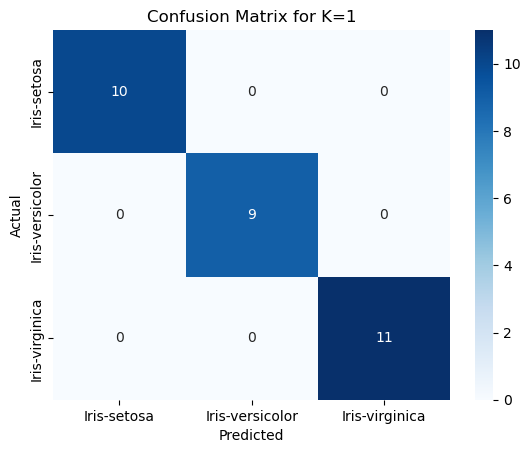

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title(f'Confusion Matrix for K={best_k}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 5. Decision boundaries
Decision Boundary visualization using 2D PCA-reduced Iris data.

In [23]:
def plotDecisionBoundary(model, X, y, class_names, padding=0.6, resolution=0.01):
    from matplotlib.colors import ListedColormap

    # Ensure X is a numpy array
    if isinstance(X, pd.DataFrame):
        X = X.values

    fig, ax = plt.subplots(figsize=(8, 6))

    # Calculate bounds
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    x_padding = (x_max - x_min) * padding
    y_padding = (y_max - y_min) * padding
    x_min -= x_padding
    x_max += x_padding
    y_min -= y_padding
    y_max += y_padding

    # Create grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = pd.factorize(Z)[0].reshape(xx.shape)  # Convert string labels to integers

    # Create custom color map
    colors = ['royalblue', 'forestgreen', 'gold']
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Plot decision boundaries
    ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    # Plot training points
    for idx, class_name in enumerate(class_names):
        indices = np.where(y == class_name)
        ax.scatter(X[indices, 0], X[indices, 1], c=colors[idx],
                   label=class_name, edgecolor='k', s=50)

    ax.set_title(f"Decision Boundary (K = {model.get_params()['n_neighbors']})")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [17]:
for label in np.unique(y_original):
    print (label)


Iris-setosa
Iris-versicolor
Iris-virginica


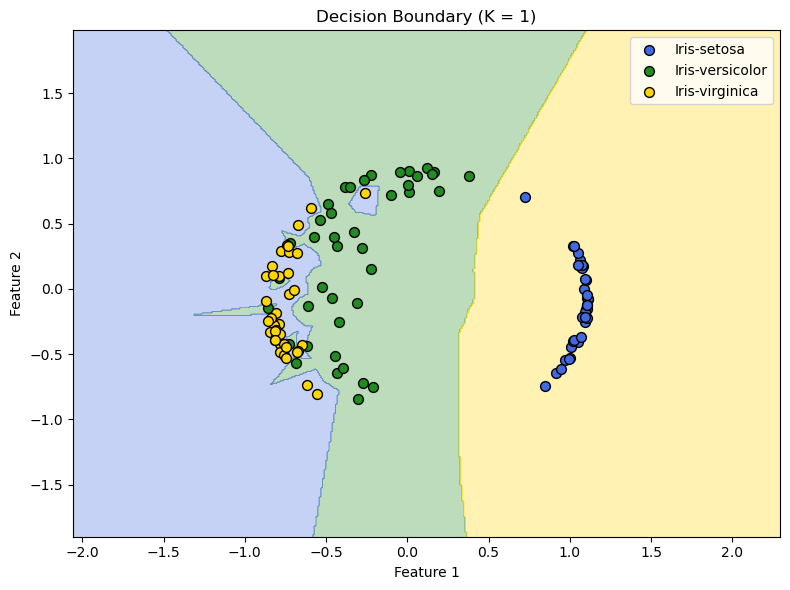

In [24]:
from sklearn.decomposition import PCA

# Reduce features to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Refit model on PCA data
knn.fit(X_train_pca, y_train)

# Call the function
plotDecisionBoundary(knn, X_train_pca, y_train.values, class_names=knn.classes_)
